# Experiment 4 : Spatial Signaling and Proliferation

**Drug Modeled:** Gefitinib

**Condition Tested:** EGFR signaling and proliferation rates in a drug gradient

**Research Question:** How do spatial drug gradients create biological response gradients?

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 5000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

In [9]:
# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

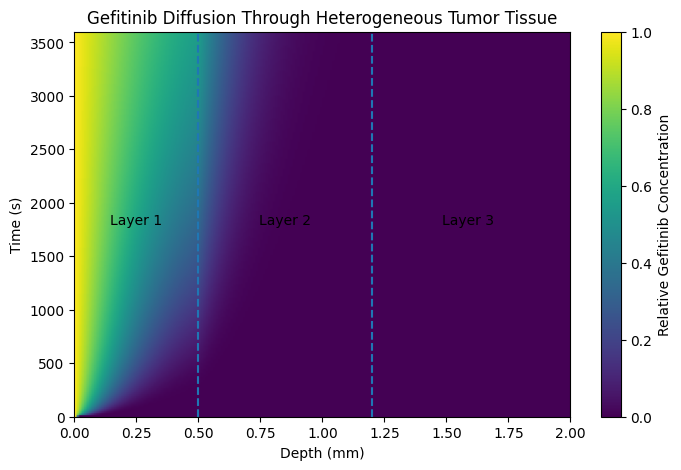

In [10]:
# Plot

C_heatmap = np.array(saved_profiles)

plt.figure(figsize=(8, 5))

plt.imshow(

    C_heatmap,

    aspect='auto',

    origin='lower',

    extent=[0, L * 10, 0, T]

)

# Labels and formatting

plt.colorbar(label='Relative Gefitinib Concentration')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Gefitinib Diffusion Through Heterogeneous Tumor Tissue')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp04_heter_map_baseline.png',
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 4A

**Figure 4A.** Spatial distribution of normalized gefitinib concentration within heterogeneous tumor tissue used as the input to the signaling model. The concentration field was generated using the heterogeneous diffusion model developed in Experiment 2 and serves as the basis for predicting spatial patterns of EGFR inhibition, ERK signaling activity, and cellular proliferation.

### Observations

* Highest gefitinib concentrations occur adjacent to the blood vessel.
* Concentration decreases with increasing tissue depth.
* The dense middle layer produces reduced drug penetration into deeper tissue.
* Spatial concentration gradients persist throughout the tumor.

### Interpretation

The concentration field represents the local drug exposure experienced by cells throughout the tumor. Because EGFR inhibition depends on local gefitinib concentration, different regions are expected to experience different levels of receptor inhibition. The heterogeneous concentration distribution establishes the initial conditions for downstream signaling analysis.

### Discussion

The heterogeneous concentration field generated in Experiment 2 provides the spatial input for the pharmacodynamic model. Regions of reduced drug concentration are therefore expected to exhibit reduced EGFR inhibition relative to areas proximal to the vascular source.